# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_list = list(np.arange(1, 20))
param_list.append(None)

param_grid = {
    'max_depth': param_list,
    'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_rf, y_train_rf)

print(f"Best Max Depth: {grid_rf.best_params_['max_depth']}")
print(f"Best N Estimators: {grid_rf.best_params_['n_estimators']}")
print(f"Best Cross-Validation Accuracy: {grid_rf.best_score_:.4f}")


Best Max Depth: 11
Best N Estimators: 200
Best Cross-Validation Accuracy: 0.8624


In [ ]:
y_pred_rf = grid_rf.predict(X_test_rf)
y_pred_rf_prob = grid_rf.predict_proba(X_test_rf)[:, 1]

# Evaluate the model
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

precision_rf = precision_score(y_test_rf, y_pred_rf)
print(f"Precision: {precision_rf:.4f}")

recall_rf = recall_score(y_test_rf, y_pred_rf)
print(f"Recall: {recall_rf:.4f}")

f1_rf = f1_score(y_test_rf, y_pred_rf)
print(f"F1 Score: {f1_rf:.4f}")

roc_auc = roc_auc_score(y_test_rf, y_pred_rf_prob)
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9067
Precision: 0.9333
Recall: 0.8861
F1 Score: 0.9091
ROC AUC: 0.9553


In [ ]:
cm = confusion_matrix(y_test_rf, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print(f"True Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")


print(f"Total Test Samples: {len(y_test)}")

True Positive (TP): 70
False Positive (FP): 5
True Negative (TN): 66
False Negative (FN): 9
Total Test Samples: 150


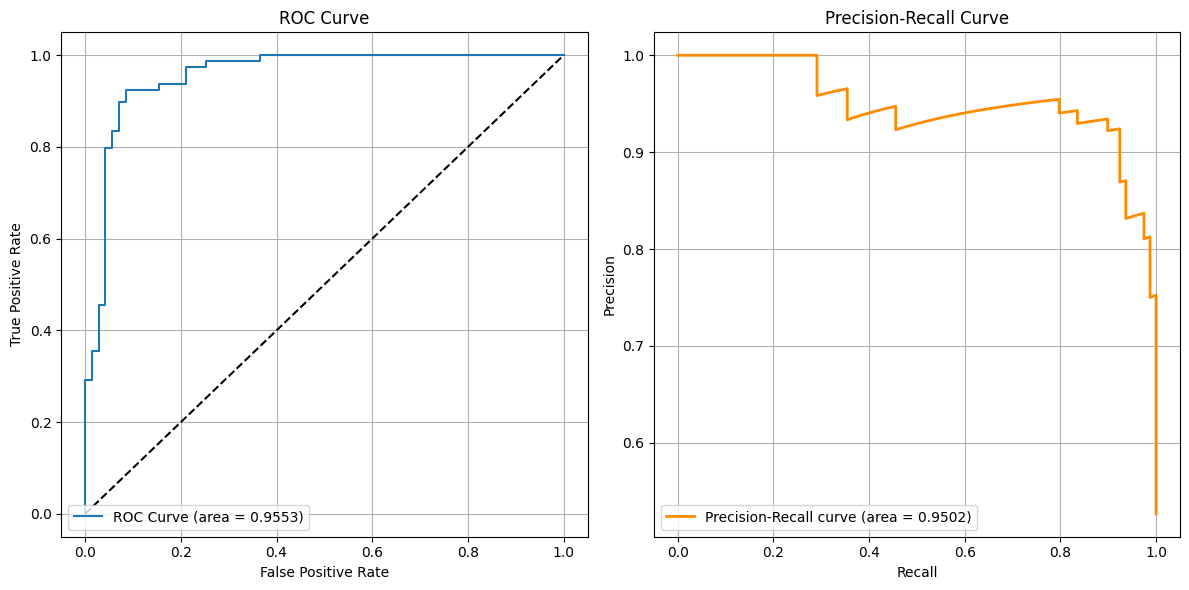

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_rf, y_pred_rf_prob)

precision, recall, thresholds = precision_recall_curve(y_test_rf, y_pred_rf_prob)
average_precision = average_precision_score(y_test_rf, y_pred_rf_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower left")
ax1.grid(True)

ax2.plot(recall, precision, lw=2, color='darkorange', label=f'Precision-Recall curve (area = {average_precision:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
best_rf = grid_rf.best_estimator_

important_features = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

important_features

,Feature,Importance
14,ST_Slope_Up,0.157258
4,MaxHR,0.125839
12,ExerciseAngina_Y,0.113164
13,ST_Slope_Flat,0.109014
0,Age,0.096027
1,RestingBP,0.082422
2,Cholesterol,0.080508
5,Oldpeak,0.078007
6,Sex_M,0.036866
7,ChestPainType_ATA,0.033517
